In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

## Plotting Utilities

The `plot_comparison_with_ratio()` function creates ATLAS-style comparison plots with:

**Main plot features:**
- Uses `plt.errorbar()` with bin widths as x-errors (horizontal bars)
- Y-errors calculated as sqrt(N) for Poisson statistics
- Supports log scale on both axes
- Can normalize to density if needed

**Ratio plot features:**
- Shows ratio of data1/data2 (Native/ACTS by default)
- Full error propagation using standard error formula
- Handles edge cases: division by zero, both bins empty
- Reference line at ratio = 1.0
- Automatic y-axis range (can be adjusted)

**Usage example:**
```python
fig, axes = plot_comparison_with_ratio(
    native_data, acts_data,
    bins=50,
    label1="Native", label2="ACTS",
    xlabel="Variable", ylabel="Counts",
    title="Comparison Plot",
    log_scale=True
)
```


In [4]:
def plot_comparison_with_ratio(data1, data2, bins, label1="Native", label2="ACTS", 
                                xlabel="Variable", ylabel="Counts", title="Comparison",
                                log_scale=False, density=False, figsize=(10, 8)):
    """
    Plot two distributions with ATLAS-style error bars and a ratio plot below.
    
    Uses errorbar with:
    - X errors: bin widths (ATLAS convention)
    - Y errors: Poisson errors (sqrt(N) for counts, properly scaled for density)
    - Ratio plot with full error propagation
    
    Parameters
    ----------
    data1 : array-like
        First dataset (e.g., Native simulation)
    data2 : array-like
        Second dataset (e.g., ACTS simulation)
    bins : int or array-like
        Bin edges or number of bins
    label1 : str
        Label for first dataset
    label2 : str
        Label for second dataset
    xlabel : str
        X-axis label
    ylabel : str
        Y-axis label
    title : str
        Plot title
    log_scale : bool
        Whether to use log scale on y-axis
    density : bool
        Whether to normalize histograms
    figsize : tuple
        Figure size (width, height)
    
    Returns
    -------
    fig, (ax_main, ax_ratio) : matplotlib figure and axes
    """
    
    fig = plt.figure(figsize=figsize)
    
    # Create gridspec for main plot and ratio plot
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    # Compute histograms
    counts1, bin_edges = np.histogram(data1, bins=bins, density=density)
    counts2, _ = np.histogram(data2, bins=bins, density=density)
    
    # Calculate bin centers and widths
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = bin_edges[1:] - bin_edges[:-1]
    
    # Calculate errors (Poisson: sqrt(N))
    # For density normalized, scale errors appropriately
    if density:
        # Need to get raw counts for proper error calculation
        raw_counts1, _ = np.histogram(data1, bins=bins)
        raw_counts2, _ = np.histogram(data2, bins=bins)
        
        # Scale factor for normalization
        scale1 = counts1 / (raw_counts1 + 1e-10)
        scale2 = counts2 / (raw_counts2 + 1e-10)
        
        errors1 = np.sqrt(raw_counts1) * scale1
        errors2 = np.sqrt(raw_counts2) * scale2
    else:
        errors1 = np.sqrt(counts1)
        errors2 = np.sqrt(counts2)
    
    # Main plot with error bars
    ax_main.errorbar(bin_centers, counts1, yerr=errors1, xerr=bin_widths/2,
                     fmt='o', label=label1, markersize=4, capsize=2, 
                     linewidth=1, elinewidth=1)
    ax_main.errorbar(bin_centers, counts2, yerr=errors2, xerr=bin_widths/2,
                     fmt='s', label=label2, markersize=4, capsize=2,
                     linewidth=1, elinewidth=1)
    
    ax_main.set_ylabel(ylabel, fontsize=12)
    ax_main.set_title(title, fontsize=14, pad=10)
    ax_main.legend(loc='best', fontsize=10)
    ax_main.grid(True, alpha=0.3)

    
    # Add ATLAS label to main plot
    atl.atlasify()
    
    if log_scale:
        ax_main.set_yscale('log')
    
    # Remove x-axis labels from main plot
    ax_main.tick_params(labelbottom=False)
    
    # Ratio plot
    # Handle division by zero and cases where both are zero
    ratio = np.ones_like(counts1, dtype=float)
    ratio_err = np.zeros_like(counts1, dtype=float)
    
    for i in range(len(counts1)):
        if counts2[i] > 0:
            ratio[i] = counts1[i] / counts2[i]
            # Error propagation: sigma_ratio = ratio * sqrt((sigma1/counts1)^2 + (sigma2/counts2)^2)
            if counts1[i] > 0:
                ratio_err[i] = ratio[i] * np.sqrt((errors1[i]/counts1[i])**2 + (errors2[i]/counts2[i])**2)
            else:
                ratio_err[i] = errors1[i] / counts2[i] if counts2[i] > 0 else 0
        elif counts1[i] > 0:
            # If denominator is zero but numerator is not, set a large ratio
            ratio[i] = np.nan  # Will not be plotted
            ratio_err[i] = 0
        else:
            # Both are zero
            ratio[i] = 1.0
            ratio_err[i] = 0
    
    ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, xerr=bin_widths/2,
                      fmt='o', markersize=4, capsize=2, color='black',
                      linewidth=1, elinewidth=1)
    ax_ratio.axhline(y=1, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax_ratio.set_xlabel(xlabel, fontsize=12)
    ax_ratio.set_ylabel(f'{label1}/{label2}', fontsize=10)
    ax_ratio.grid(True, alpha=0.3)
    ax_ratio.set_ylim([0.5, 1.5])  # Adjust as needed
    
    
    plt.tight_layout()
    
    return fig, (ax_main, ax_ratio)


## Roadmap

1. Load edm4hep files (ACTS and Native simulations)
2. Load the particles and tracker hits
3. Compare statistics between simulations
4. Create ATLAS-style comparison plots with ratio panels

**Note**: All comparison plots use ATLAS conventions:
- Error bars with bin widths (x-error) and Poisson errors (y-error)
- Ratio plot below main histogram showing Native/ACTS
- Proper error propagation in ratio calculation
- ColliderML label in upper right


## Loading

In [5]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

native_edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_pion/v2/runs/all/edm4hep.root"
native_batch = EDM4hepEventBatch(native_edm_input_file, events=(0, 1000), full_load=False, detector_params=detector_params)

acts_edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_pion/v1/runs/all/edm4hep.root"
acts_batch = EDM4hepEventBatch(acts_edm_input_file, events=(0, 1000), full_load=False, detector_params=detector_params)

acts_loguniform_edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_pion/v3/runs/all/edm4hep.root"
acts_loguniform_batch = EDM4hepEventBatch(acts_loguniform_edm_input_file, events=(0, 1000), full_load=False, detector_params=detector_params)


In [6]:
acts_hits = acts_batch.get_tracker_hits_df()
acts_particles = acts_batch.get_particles_df()

acts_loguniform_hits = acts_loguniform_batch.get_tracker_hits_df()
acts_loguniform_particles = acts_loguniform_batch.get_particles_df()

native_hits = native_batch.get_tracker_hits_df()
native_particles = native_batch.get_particles_df()


Augmenting particle hit counts with tracker hits
Augmenting particle hit counts with tracker hits
Augmenting particle hit counts with tracker hits


## Statistics Comparison


In [32]:
print("=" * 80)
print("NATIVE SIMULATION STATISTICS")
print("=" * 80)
print(f"\nHits:")
print(f"  Total hits: {len(native_hits)}")
print(f"  Hits per event: {native_hits.groupby('event_id').size().describe()}")
print(f"\nParticles:")
print(f"  Total particles: {len(native_particles)}")
print(f"  Particles per event: {native_particles.groupby('event_id').size().describe()}")
print(f"  Particles created in simulation: {native_particles['created_in_simulation'].sum()}")
print(f"  Particles created inside tracker: {native_particles['created_inside_tracker'].sum()}")

print("\n" + "=" * 80)
print("ACTS SIMULATION STATISTICS")
print("=" * 80)
print(f"\nHits:")
print(f"  Total hits: {len(acts_hits)}")
print(f"  Hits per event: {acts_hits.groupby('event_id').size().describe()}")
print(f"\nParticles:")
print(f"  Total particles: {len(acts_particles)}")
print(f"  Particles per event: {acts_particles.groupby('event_id').size().describe()}")
print(f"  Particles created in simulation: {acts_particles['created_in_simulation'].sum()}")
if 'created_inside_tracker' in acts_particles.columns:
    print(f"  Particles created inside tracker: {acts_particles['created_inside_tracker'].sum()}")


NATIVE SIMULATION STATISTICS

Hits:
  Total hits: 86253
  Hits per event: count    1000.000000
mean       86.253000
std       133.553306
min         6.000000
25%        18.000000
50%        34.000000
75%        95.000000
max      1203.000000
dtype: float64

Particles:
  Total particles: 1293085
  Particles per event: count    1000.000000
mean     1293.085000
std       881.588537
min         1.000000
25%       533.000000
50%      1220.500000
75%      1975.000000
max      3825.000000
dtype: float64
  Particles created in simulation: 1292085
  Particles created inside tracker: 38064

ACTS SIMULATION STATISTICS

Hits:
  Total hits: 80686
  Hits per event: count    1000.000000
mean       80.686000
std       124.886469
min         6.000000
25%        18.000000
50%        33.000000
75%        84.000000
max       990.000000
dtype: float64

Particles:
  Total particles: 1303391
  Particles per event: count    1000.000000
mean     1303.391000
std       880.991636
min         2.000000
25%       4

In [33]:
# Comparison summary
print("=" * 80)
print("COMPARISON SUMMARY")
print("=" * 80)
print(f"\nHits difference:")
print(f"  Native: {len(native_hits)}, ACTS: {len(acts_hits)}, Diff: {len(native_hits) - len(acts_hits)}")
print(f"  Ratio (Native/ACTS): {len(native_hits) / len(acts_hits):.2f}")

print(f"\nParticles difference:")
print(f"  Native: {len(native_particles)}, ACTS: {len(acts_particles)}, Diff: {len(native_particles) - len(acts_particles)}")
print(f"  Ratio (Native/ACTS): {len(native_particles) / len(acts_particles):.2f}")

print(f"\nParticles created in simulation:")
print(f"  Native: {native_particles['created_in_simulation'].sum()}, ACTS: {acts_particles['created_in_simulation'].sum()}")
print(f"  Diff: {native_particles['created_in_simulation'].sum() - acts_particles['created_in_simulation'].sum()}")


COMPARISON SUMMARY

Hits difference:
  Native: 86253, ACTS: 80686, Diff: 5567
  Ratio (Native/ACTS): 1.07

Particles difference:
  Native: 1293085, ACTS: 1303391, Diff: -10306
  Ratio (Native/ACTS): 0.99

Particles created in simulation:
  Native: 1292085, ACTS: 1301391
  Diff: -9306


## Comparison Plots


/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


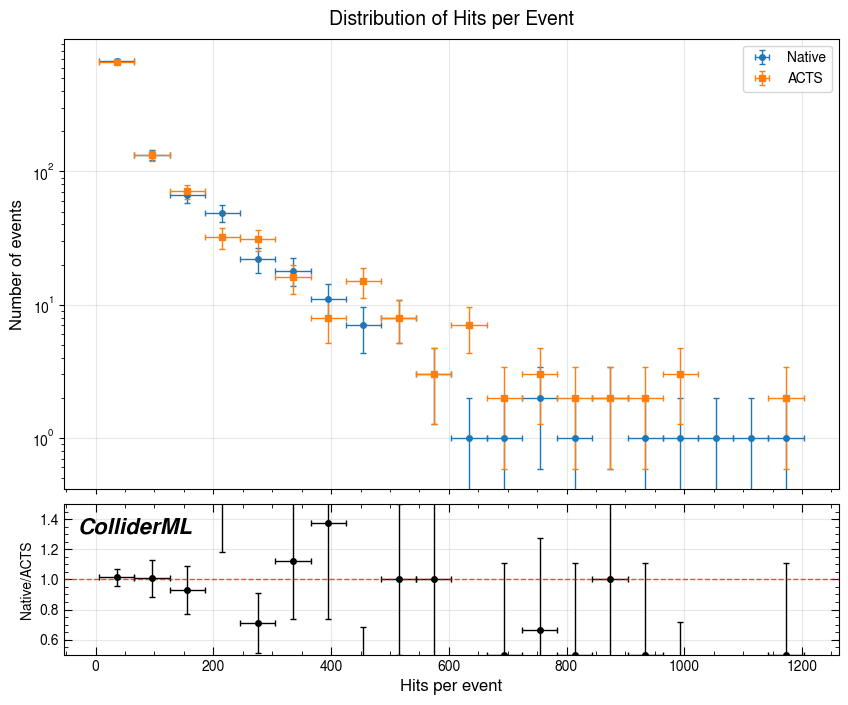

In [44]:
# Plot 1: Number of hits per event
native_hits_per_event = native_hits.groupby('event_id').size()
acts_hits_per_event = acts_hits.groupby('event_id').size()

fig, axes = plot_comparison_with_ratio(
    native_hits_per_event, 
    acts_hits_per_event,
    bins=20,
    label1="Native",
    label2="ACTS",
    xlabel="Hits per event",
    ylabel="Number of events",
    title="Distribution of Hits per Event",
    log_scale=True
)
plt.show()


/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


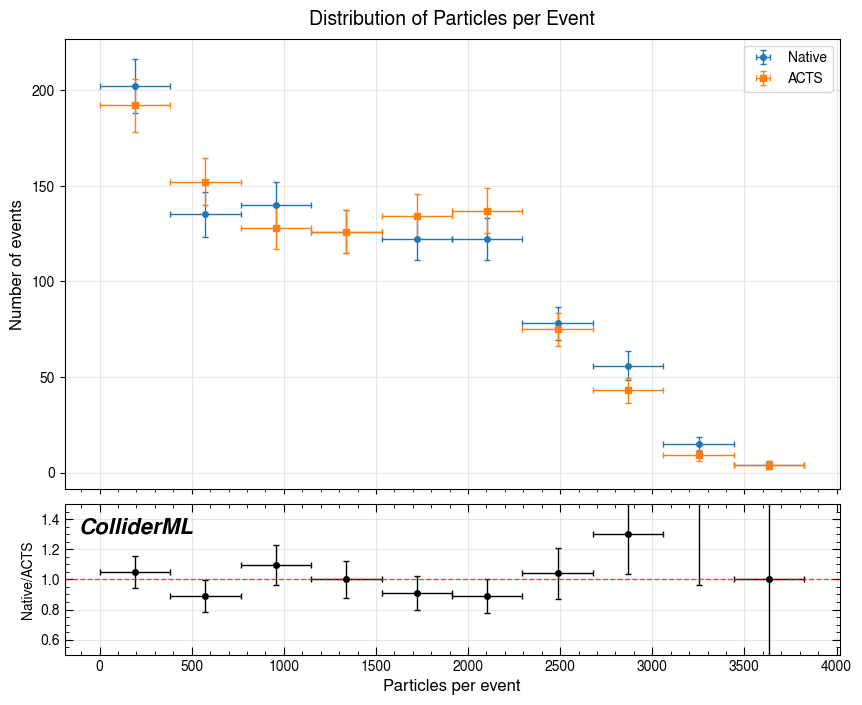

In [46]:
# Plot 2: Particles per event
native_particles_per_event = native_particles.groupby('event_id').size()
acts_particles_per_event = acts_particles.groupby('event_id').size()

fig, axes = plot_comparison_with_ratio(
    native_particles_per_event,
    acts_particles_per_event,
    bins=10,
    label1="Native",
    label2="ACTS",
    xlabel="Particles per event",
    ylabel="Number of events",
    title="Distribution of Particles per Event",
    log_scale=False
)
plt.show()


/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


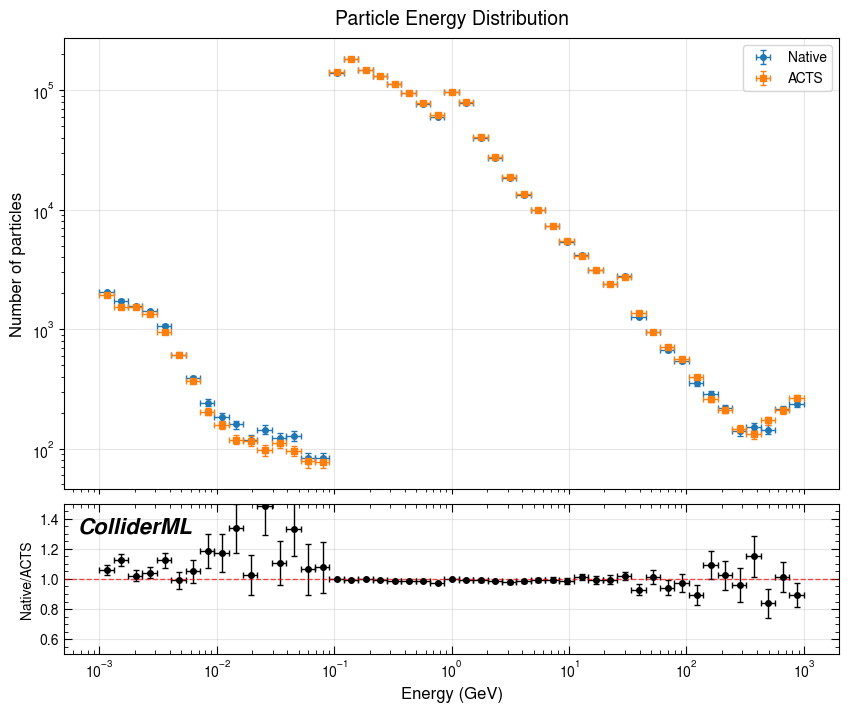

In [47]:
# Plot 3: Energy distribution comparison (log scale with log-spaced bins)
energy_min = min(native_particles['energy'].min(), acts_particles['energy'].min())
energy_max = max(native_particles['energy'].max(), acts_particles['energy'].max())
energy_log_bins = np.logspace(np.log10(max(energy_min, 1e-3)), np.log10(energy_max), 50)

fig, axes = plot_comparison_with_ratio(
    native_particles['energy'],
    acts_particles['energy'],
    bins=energy_log_bins,
    label1="Native",
    label2="ACTS",
    xlabel="Energy (GeV)",
    ylabel="Number of particles",
    title="Particle Energy Distribution",
    log_scale=True
)
axes[0].set_xscale('log')
axes[1].set_xscale('log')
plt.show()


/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


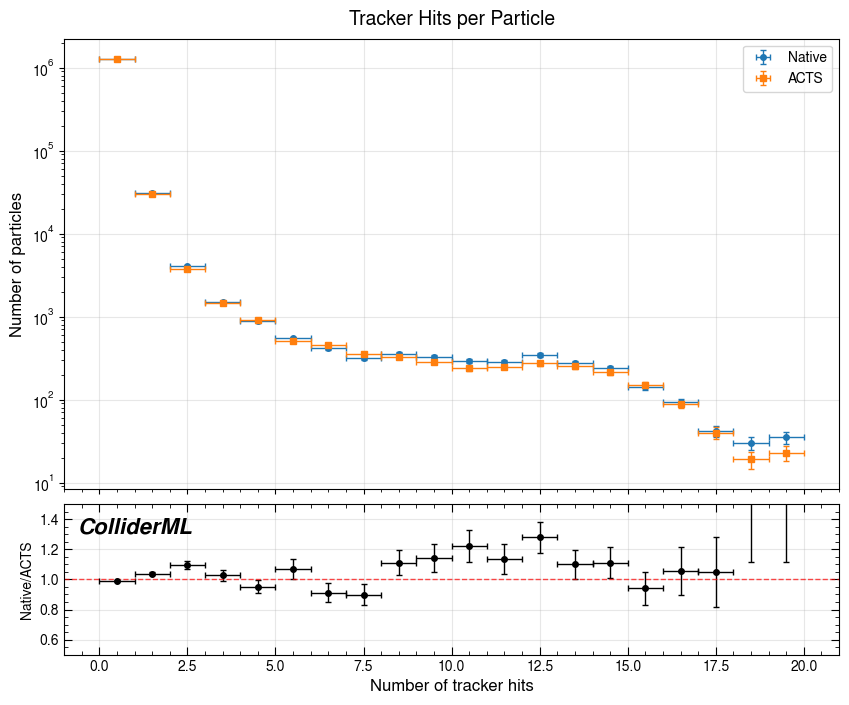

In [48]:
# Plot 4: Number of tracker hits per particle
fig, axes = plot_comparison_with_ratio(
    native_particles['num_tracker_hits'],
    acts_particles['num_tracker_hits'],
    bins=range(0, 21),
    label1="Native",
    label2="ACTS",
    xlabel="Number of tracker hits",
    ylabel="Number of particles",
    title="Tracker Hits per Particle",
    log_scale=True
)
plt.show()


In [ ]:
# Plot: PDG distribution comparison
# Get unique PDG codes from both datasets
all_pdg_codes = sorted(set(native_particles['PDG'].unique()) | set(acts_particles['PDG'].unique()))

# Create bins centered on PDG codes (with 0.5 spacing to center bars)
pdg_bins = np.array(all_pdg_codes + [all_pdg_codes[-1] + 1]) - 0.5

fig, axes = plot_comparison_with_ratio(
    native_particles['PDG'],
    acts_particles['PDG'],
    bins=pdg_bins,
    label1="Native",
    label2="ACTS",
    xlabel="PDG Code",
    ylabel="Number of particles",
    title="Particle PDG Distribution",
    log_scale=True
)
# Set x-axis ticks to actual PDG codes for readability
axes[0].set_xticks(all_pdg_codes)
axes[0].set_xticklabels(all_pdg_codes, rotation=45, ha='right')
axes[1].set_xticks(all_pdg_codes)
axes[1].set_xticklabels(all_pdg_codes, rotation=45, ha='right')
plt.show()


/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
Locator attempting to generate 550084482 ticks ([-50011002.0, ..., 1050157960.0]), which exceeds Locator.MAXTICKS (1000).


/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


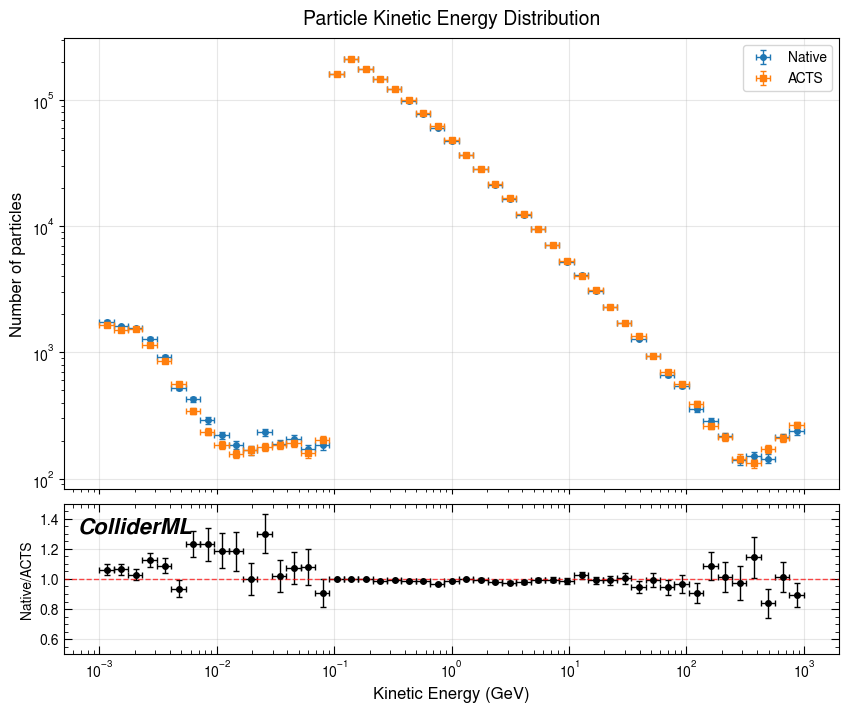

In [49]:
# Plot 5: Kinetic energy distribution
ke_min = min(native_particles['kinetic_energy'].min(), acts_particles['kinetic_energy'].min())
ke_max = max(native_particles['kinetic_energy'].max(), acts_particles['kinetic_energy'].max())
ke_log_bins = np.logspace(np.log10(max(ke_min, 1e-3)), np.log10(ke_max), 50)

fig, axes = plot_comparison_with_ratio(
    native_particles['kinetic_energy'],
    acts_particles['kinetic_energy'],
    bins=ke_log_bins,
    label1="Native",
    label2="ACTS",
    xlabel="Kinetic Energy (GeV)",
    ylabel="Number of particles",
    title="Particle Kinetic Energy Distribution",
    log_scale=True
)
axes[0].set_xscale('log')
axes[1].set_xscale('log')
plt.show()


/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


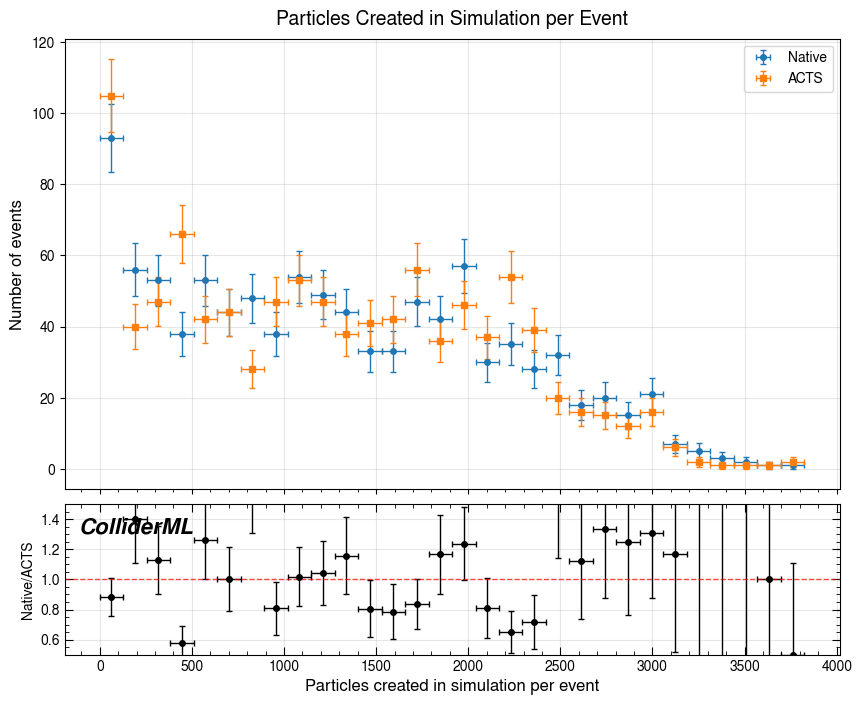

In [50]:
# Plot 6: Particles created in simulation per event
native_created_sim_per_event = native_particles[native_particles['created_in_simulation']].groupby('event_id').size()
acts_created_sim_per_event = acts_particles[acts_particles['created_in_simulation']].groupby('event_id').size()

# Align to same events (some events might have 0 particles created in sim)
all_events = sorted(set(native_particles['event_id'].unique()) | set(acts_particles['event_id'].unique()))
native_created_array = np.array([native_created_sim_per_event.get(e, 0) for e in all_events])
acts_created_array = np.array([acts_created_sim_per_event.get(e, 0) for e in all_events])

fig, axes = plot_comparison_with_ratio(
    native_created_array,
    acts_created_array,
    bins=30,
    label1="Native",
    label2="ACTS",
    xlabel="Particles created in simulation per event",
    ylabel="Number of events",
    title="Particles Created in Simulation per Event",
    log_scale=False
)
plt.show()


In [72]:
native_particles.columns

Index(['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
       'parents_end', 'vr', 'energy', 'kinetic_energy', 'particle_id',
       'created_in_simulation', 'num_tracker_hits', 'num_calo_hits',
       'created_inside_tracker'],
      dtype='object')

/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


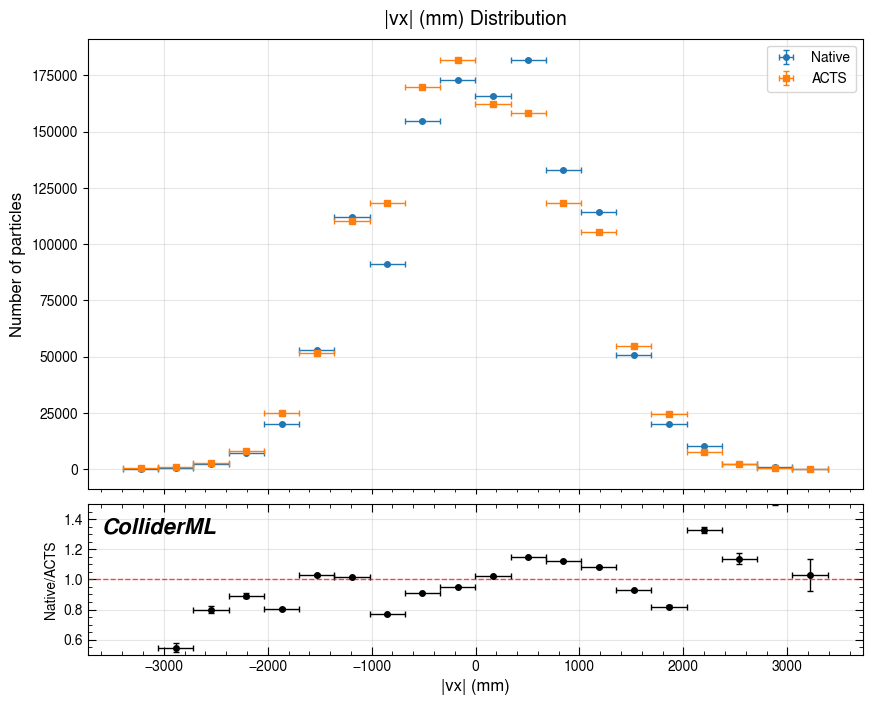

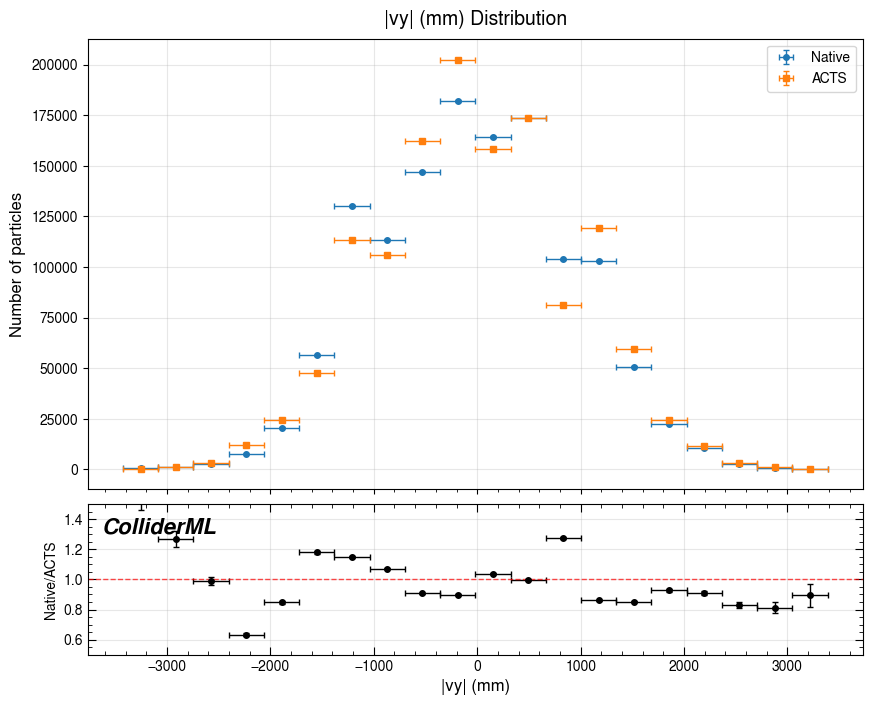

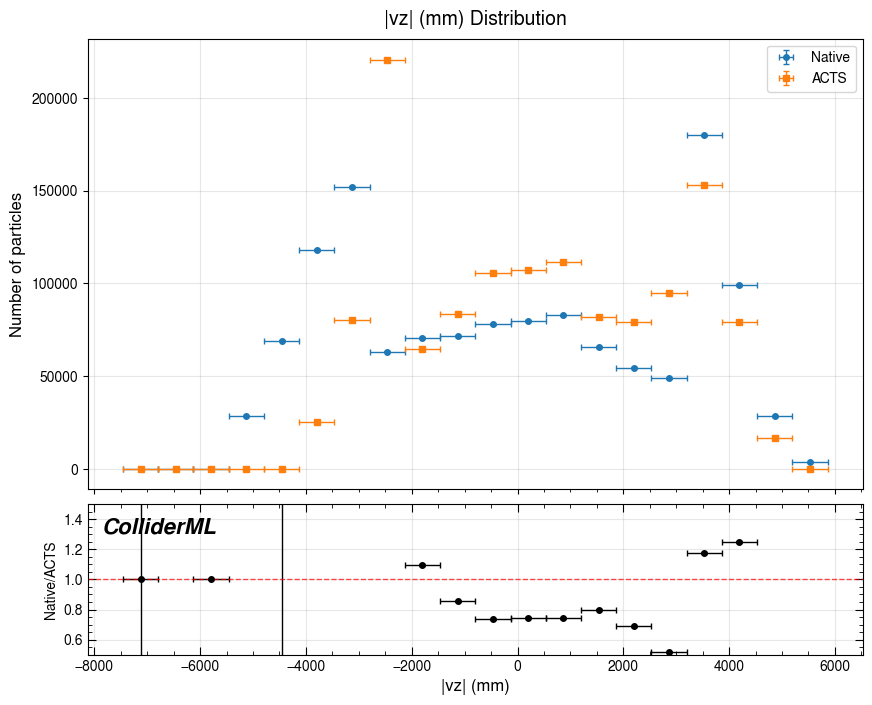

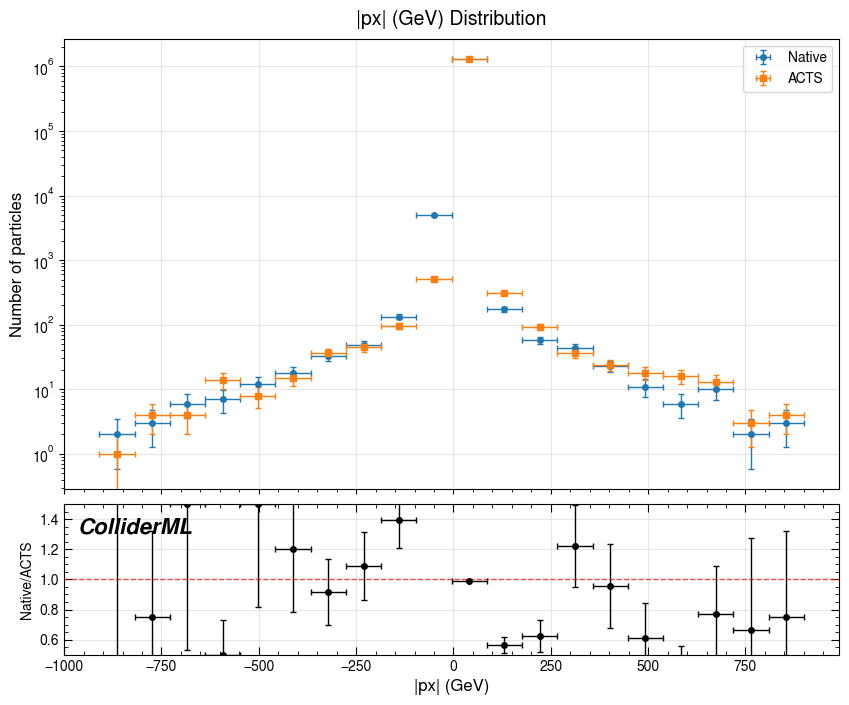

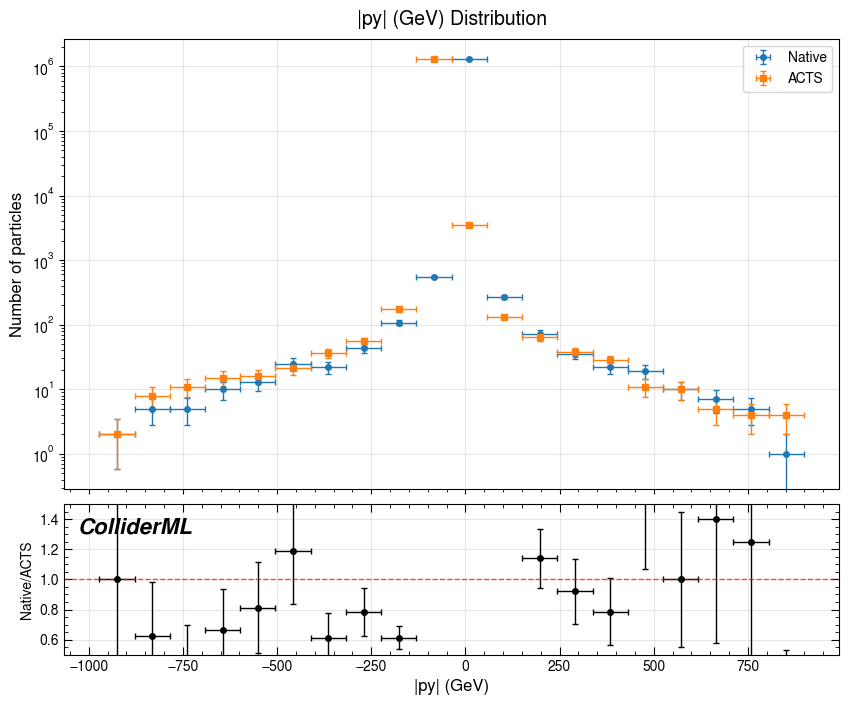

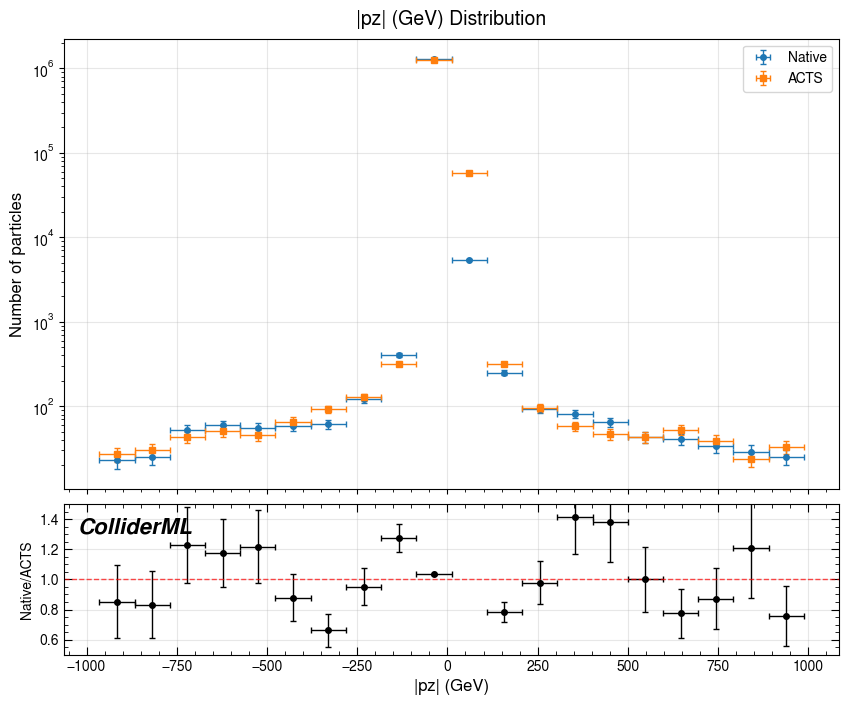

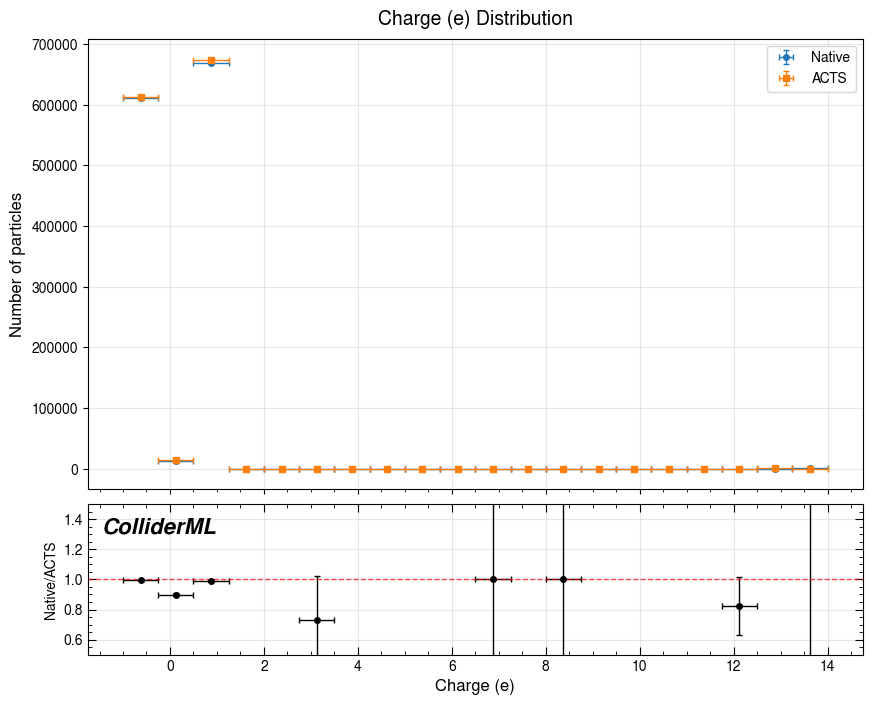

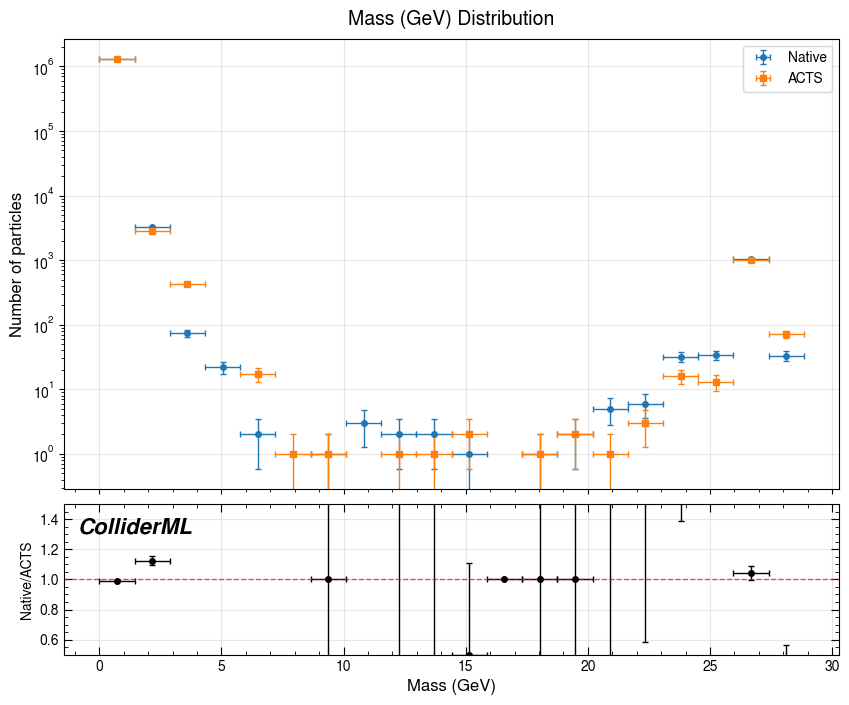

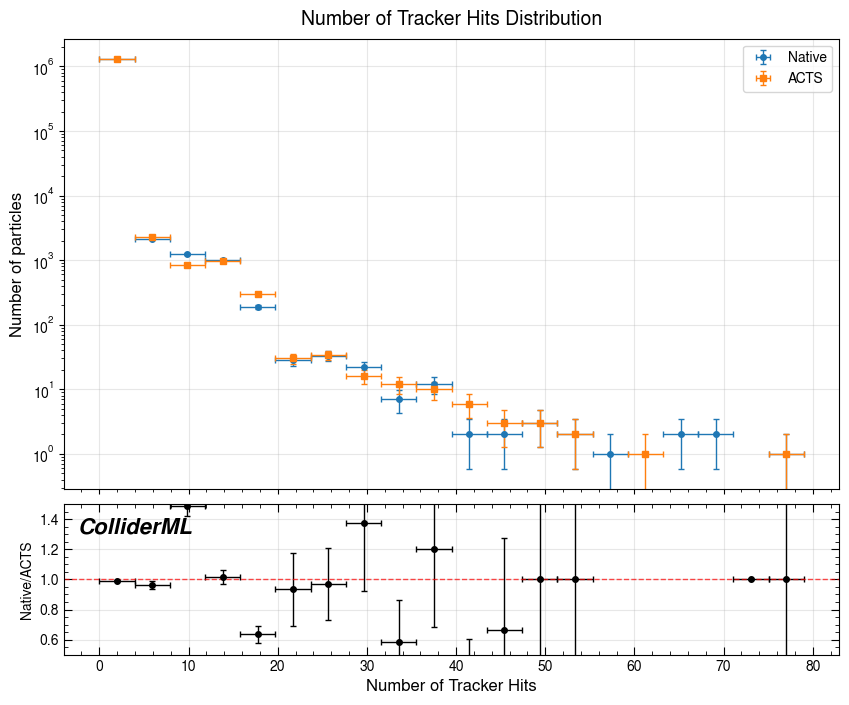

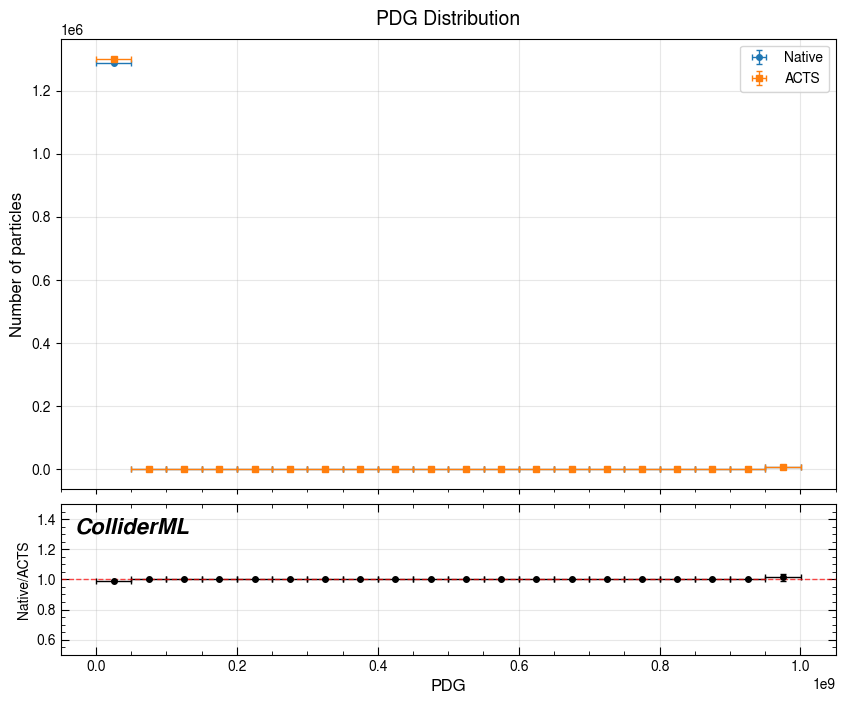

In [ ]:
# Define columns to plot with their properties (excluding PDG - handled separately)
plot_configs = [
    {'col': 'vx', 'label': '|vx| (mm)', 'log': False, 'abs': True},
    {'col': 'vy', 'label': '|vy| (mm)', 'log': False, 'abs': True},
    {'col': 'vz', 'label': '|vz| (mm)', 'log': False, 'abs': True},
    {'col': 'px', 'label': '|px| (GeV)', 'log': True, 'abs': True},
    {'col': 'py', 'label': '|py| (GeV)', 'log': True, 'abs': True},
    {'col': 'pz', 'label': '|pz| (GeV)', 'log': True, 'abs': True},
    {'col': 'charge', 'label': 'Charge (e)', 'log': False, 'abs': False},
    {'col': 'mass', 'label': 'Mass (GeV)', 'log': True, 'abs': False},
    {'col': 'num_tracker_hits', 'label': 'Number of Tracker Hits', 'log': True, 'abs': False},
    # PDG is handled separately below due to categorical nature
]

for config in plot_configs:
    col = config['col']
    label = config['label']
    use_log = config['log']
    use_abs = config['abs']
    if use_abs:
        native_data = np.abs(native_particles[col])
        acts_data = np.abs(acts_particles[col])
    else:
        native_data = native_particles[col]
        acts_data = acts_particles[col]
    
    plot_comparison_with_ratio(
        native_data,
        acts_data,
        xlabel=label,
        ylabel="Number of particles",
        title=f"{label} Distribution",
        bins=30,
        log_scale=use_log,
        label1="Native",
        label2="ACTS",
    )

### PDG Distribution (Categorical Plotting)

For PDG codes, we need a different approach since they're categorical (not continuous) and some codes are very large.


In [1]:
# Better PDG plotting: Show top N most common particles
# Count occurrences of each PDG code
native_pdg_counts = native_particles['PDG'].value_counts()
acts_pdg_counts = acts_particles['PDG'].value_counts()

# Get top N most common PDG codes from both datasets combined
all_pdg_counts = native_pdg_counts.add(acts_pdg_counts, fill_value=0)
top_n = 20
top_pdg_codes = all_pdg_counts.nlargest(top_n).index.tolist()

# Filter particles to only include top PDG codes
native_top_pdg = native_particles[native_particles['PDG'].isin(top_pdg_codes)]
acts_top_pdg = acts_particles[acts_particles['PDG'].isin(top_pdg_codes)]

# Create a mapping from PDG codes to sequential integers for plotting
pdg_to_idx = {pdg: i for i, pdg in enumerate(sorted(top_pdg_codes))}
idx_to_pdg = {i: pdg for pdg, i in pdg_to_idx.items()}

# Map PDG codes to indices
native_indices = native_top_pdg['PDG'].map(pdg_to_idx).values
acts_indices = acts_top_pdg['PDG'].map(pdg_to_idx).values

# Create bins for the indices
bins = np.arange(-0.5, len(top_pdg_codes), 1)

fig, axes = plot_comparison_with_ratio(
    native_indices,
    acts_indices,
    bins=bins,
    label1="Native",
    label2="ACTS",
    xlabel="Particle Type",
    ylabel="Number of particles",
    title=f"Particle Type Distribution (Top {top_n} Most Common)",
    log_scale=True
)

# Set x-axis ticks to actual PDG codes with particle names
tick_labels = []
tick_positions = []
for idx in range(len(top_pdg_codes)):
    pdg = idx_to_pdg[idx]
    try:
        particle_name = Particle.from_pdgid(pdg).name
        tick_labels.append(f"{particle_name}\n({pdg})")
    except:
        tick_labels.append(f"PDG\n{pdg}")
    tick_positions.append(idx)

axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)

plt.subplots_adjust(bottom=0.22)  # Make room for rotated labels
plt.show()


NameError: name 'native_particles' is not defined

In [2]:
# Print summary table of top particles
print(f"\nTop {top_n} most common particles:")
print(f"{'Rank':<6} {'PDG':<12} {'Particle Name':<25} {'Native':<12} {'ACTS':<12} {'Ratio':<10}")
print("="*85)
for rank, pdg in enumerate(sorted(top_pdg_codes, key=lambda x: all_pdg_counts[x], reverse=True), 1):
    try:
        particle_name = Particle.from_pdgid(pdg).name
    except:
        particle_name = "Unknown"
    native_count = native_pdg_counts.get(pdg, 0)
    acts_count = acts_pdg_counts.get(pdg, 0)
    ratio = native_count / acts_count if acts_count > 0 else float('inf')
    print(f"{rank:<6} {pdg:<12} {particle_name:<25} {native_count:<12.0f} {acts_count:<12.0f} {ratio:<10.3f}")


NameError: name 'top_n' is not defined

## Log Uniform Comparison Plots

/tmp/ipykernel_1011670/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


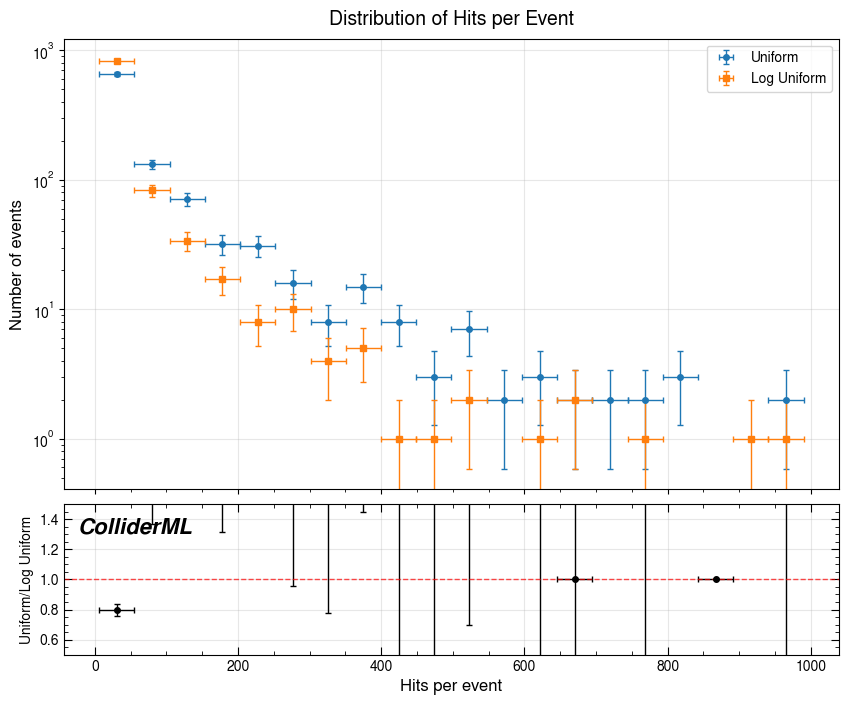

In [11]:
# Plot 1: Number of hits per event
acts_loguniform_hits_per_event = acts_loguniform_hits.groupby('event_id').size()
acts_hits_per_event = acts_hits.groupby('event_id').size()

fig, axes = plot_comparison_with_ratio(
    acts_hits_per_event,
    acts_loguniform_hits_per_event,
    bins=20,
    label1="Uniform",
    label2="Log Uniform",
    xlabel="Hits per event",
    ylabel="Number of events",
    title="Distribution of Hits per Event",
    log_scale=True
)
plt.show()


/tmp/ipykernel_1011670/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


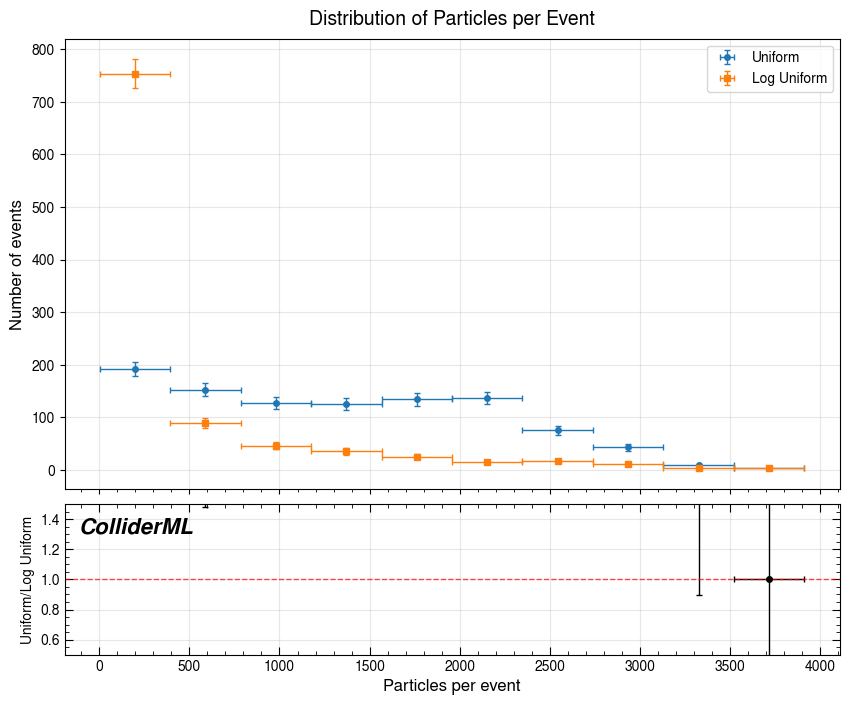

In [12]:
# Plot 2: Particles per event
acts_loguniform_particles_per_event = acts_loguniform_particles.groupby('event_id').size()
acts_particles_per_event = acts_particles.groupby('event_id').size()

fig, axes = plot_comparison_with_ratio(
    acts_particles_per_event,
    acts_loguniform_particles_per_event,
    bins=10,
    label1="Uniform",
    label2="Log Uniform",
    xlabel="Particles per event",
    ylabel="Number of events",
    title="Distribution of Particles per Event",
    log_scale=False
)
plt.show()


/tmp/ipykernel_1011670/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


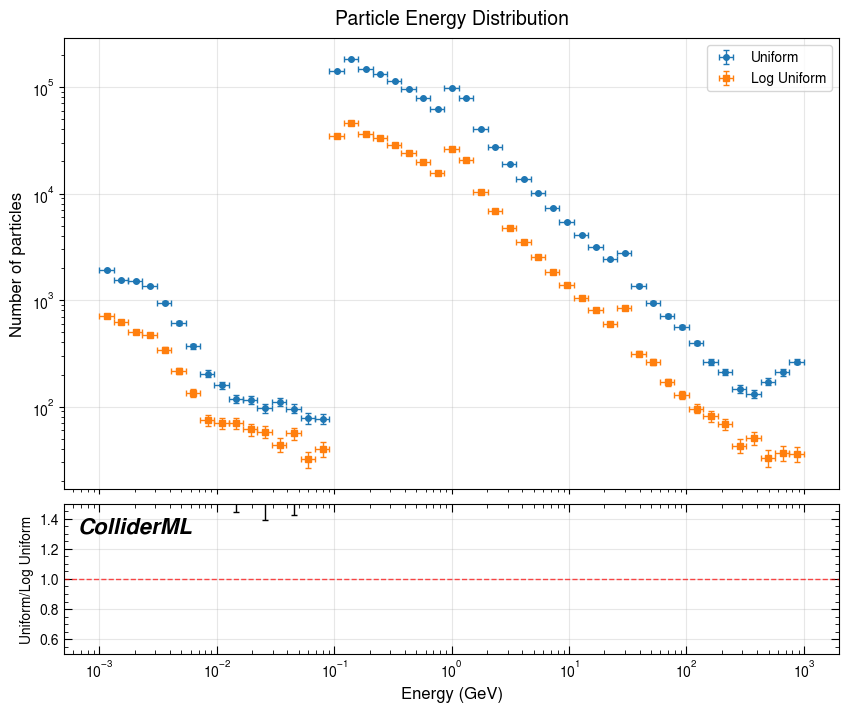

In [13]:
# Plot 3: Energy distribution comparison (log scale with log-spaced bins)
energy_min = min(acts_particles['energy'].min(), acts_loguniform_particles['energy'].min())
energy_max = max(acts_particles['energy'].max(), acts_loguniform_particles['energy'].max())
energy_log_bins = np.logspace(np.log10(max(energy_min, 1e-3)), np.log10(energy_max), 50)

fig, axes = plot_comparison_with_ratio(
    acts_particles['energy'],
    acts_loguniform_particles['energy'],
    bins=energy_log_bins,
    label1="Uniform",
    label2="Log Uniform",
    xlabel="Energy (GeV)",
    ylabel="Number of particles",
    title="Particle Energy Distribution",
    log_scale=True
)
axes[0].set_xscale('log')
axes[1].set_xscale('log')
plt.show()


/tmp/ipykernel_1011670/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


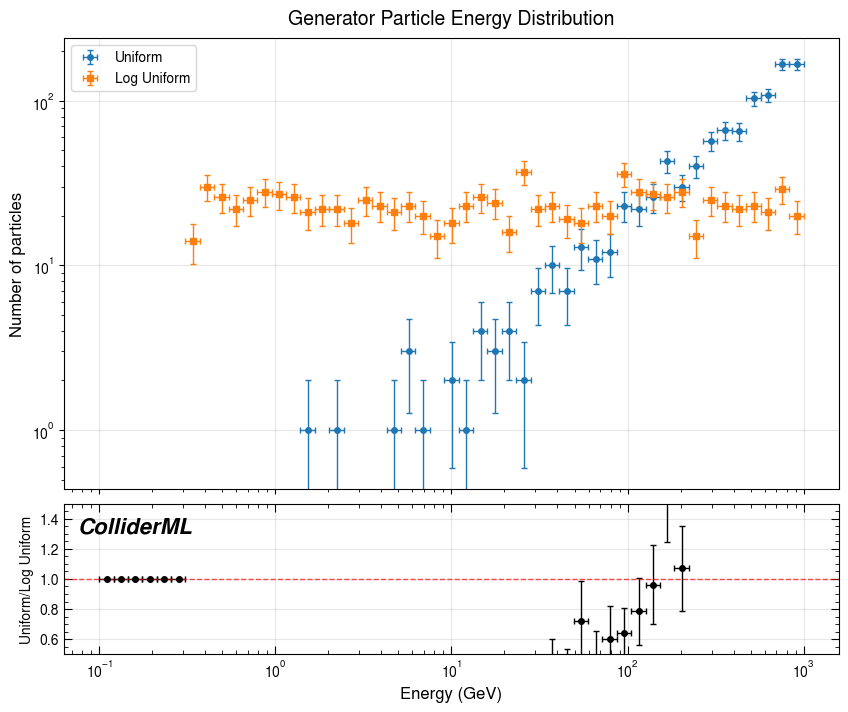

In [15]:
# Plot 3: Energy distribution comparison (log scale with log-spaced bins) of generator particles
acts_generator_particles = acts_particles[acts_particles['created_in_simulation'] == False]
acts_loguniform_generator_particles = acts_loguniform_particles[acts_loguniform_particles['created_in_simulation'] == False]

energy_min = min(acts_generator_particles['energy'].min(), acts_loguniform_generator_particles['energy'].min())
energy_max = max(acts_generator_particles['energy'].max(), acts_loguniform_generator_particles['energy'].max())
energy_log_bins = np.logspace(np.log10(0.1), np.log10(energy_max), 50)

fig, axes = plot_comparison_with_ratio(
    acts_generator_particles['energy'],
    acts_loguniform_generator_particles['energy'],
    bins=energy_log_bins,
    label1="Uniform",
    label2="Log Uniform",
    xlabel="Energy (GeV)",
    ylabel="Number of particles",
    title="Generator Particle Energy Distribution",
    log_scale=True
)
axes[0].set_xscale('log')
axes[1].set_xscale('log')
plt.show()


/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


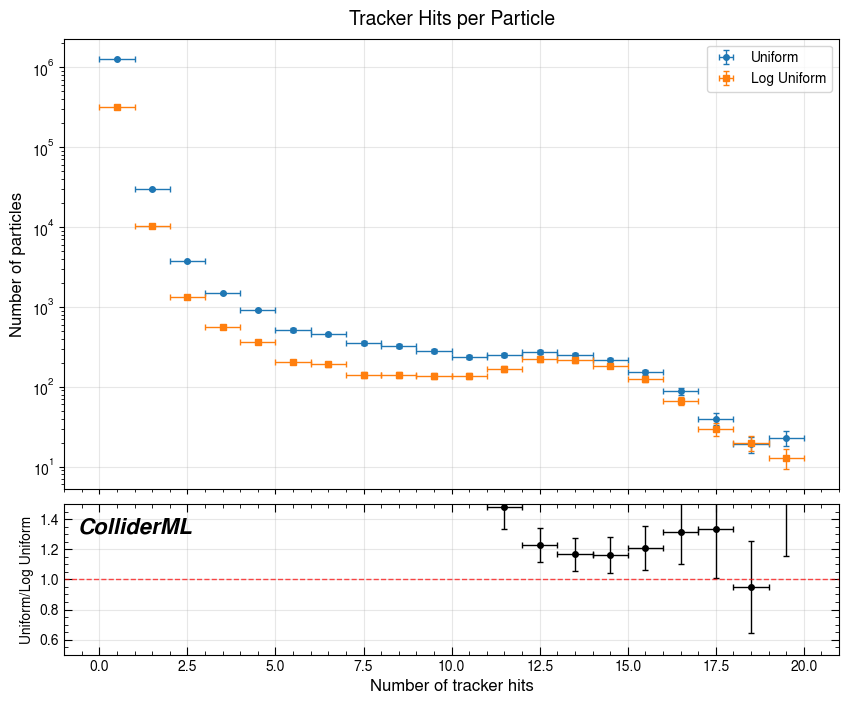

In [67]:
# Plot 4: Number of tracker hits per particle
fig, axes = plot_comparison_with_ratio(
    acts_particles['num_tracker_hits'],
    acts_loguniform_particles['num_tracker_hits'],
    bins=range(0, 21),
    label1="Uniform",
    label2="Log Uniform",
    xlabel="Number of tracker hits",
    ylabel="Number of particles",
    title="Tracker Hits per Particle",
    log_scale=True
)
plt.show()


/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


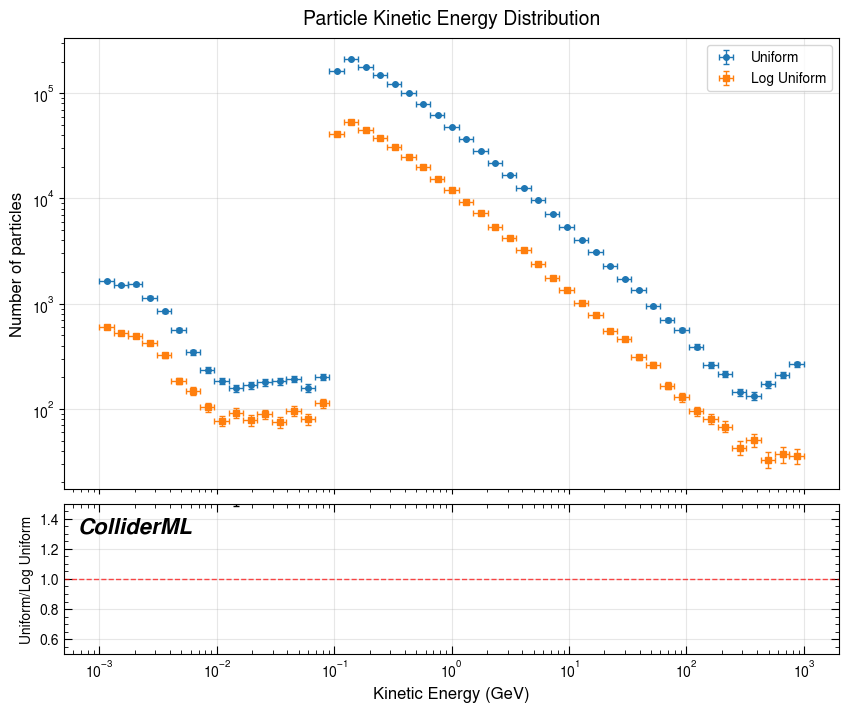

In [68]:
# Plot 5: Kinetic energy distribution
ke_min = min(acts_particles['kinetic_energy'].min(), acts_loguniform_particles['kinetic_energy'].min())
ke_max = max(acts_particles['kinetic_energy'].max(), acts_loguniform_particles['kinetic_energy'].max())
ke_log_bins = np.logspace(np.log10(max(ke_min, 1e-3)), np.log10(ke_max), 50)

fig, axes = plot_comparison_with_ratio(
    acts_particles['kinetic_energy'],
    acts_loguniform_particles['kinetic_energy'],
    bins=ke_log_bins,
    label1="Uniform",
    label2="Log Uniform",
    xlabel="Kinetic Energy (GeV)",
    ylabel="Number of particles",
    title="Particle Kinetic Energy Distribution",
    log_scale=True
)
axes[0].set_xscale('log')
axes[1].set_xscale('log')
plt.show()


/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


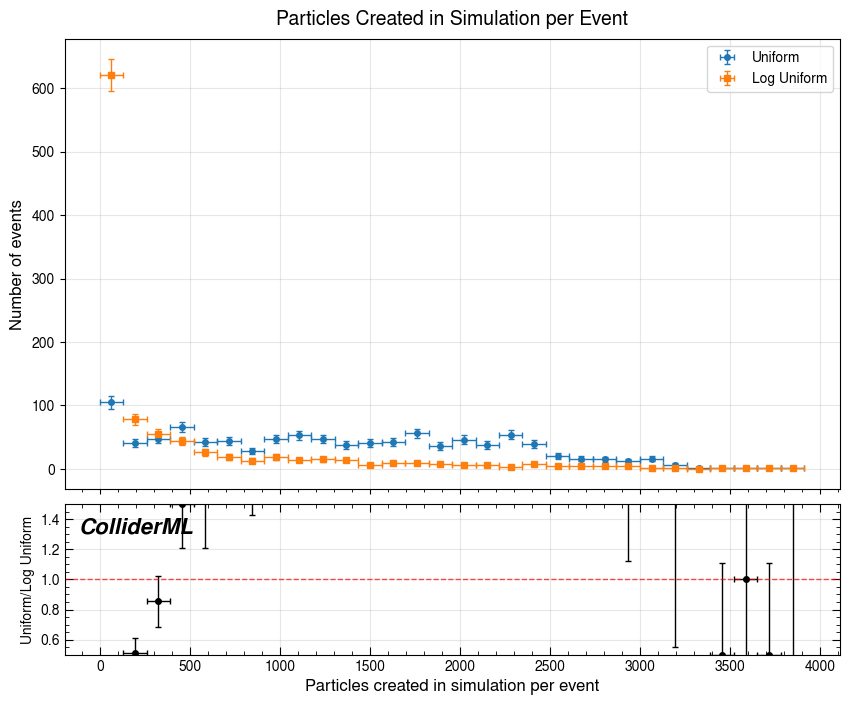

In [69]:
# Plot 6: Particles created in simulation per event
acts_loguniform_created_sim_per_event = acts_loguniform_particles[acts_loguniform_particles['created_in_simulation']].groupby('event_id').size()
acts_created_sim_per_event = acts_particles[acts_particles['created_in_simulation']].groupby('event_id').size()

# Align to same events (some events might have 0 particles created in sim)
all_events = sorted(set(acts_particles['event_id'].unique()) | set(acts_loguniform_particles['event_id'].unique()))
acts_created_array = np.array([acts_created_sim_per_event.get(e, 0) for e in all_events])
acts_loguniform_created_array = np.array([acts_loguniform_created_sim_per_event.get(e, 0) for e in all_events])

fig, axes = plot_comparison_with_ratio(
    acts_created_array,
    acts_loguniform_created_array,
    bins=30,
    label1="Uniform",
    label2="Log Uniform",
    xlabel="Particles created in simulation per event",
    ylabel="Number of events",
    title="Particles Created in Simulation per Event",
    log_scale=False
)
plt.show()


/tmp/ipykernel_847314/1857863817.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


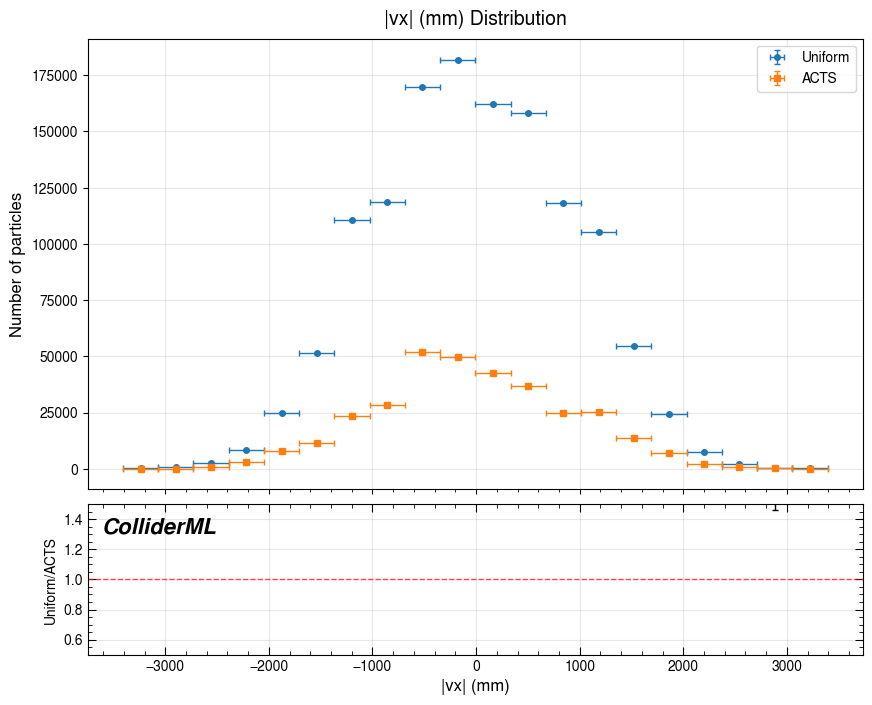

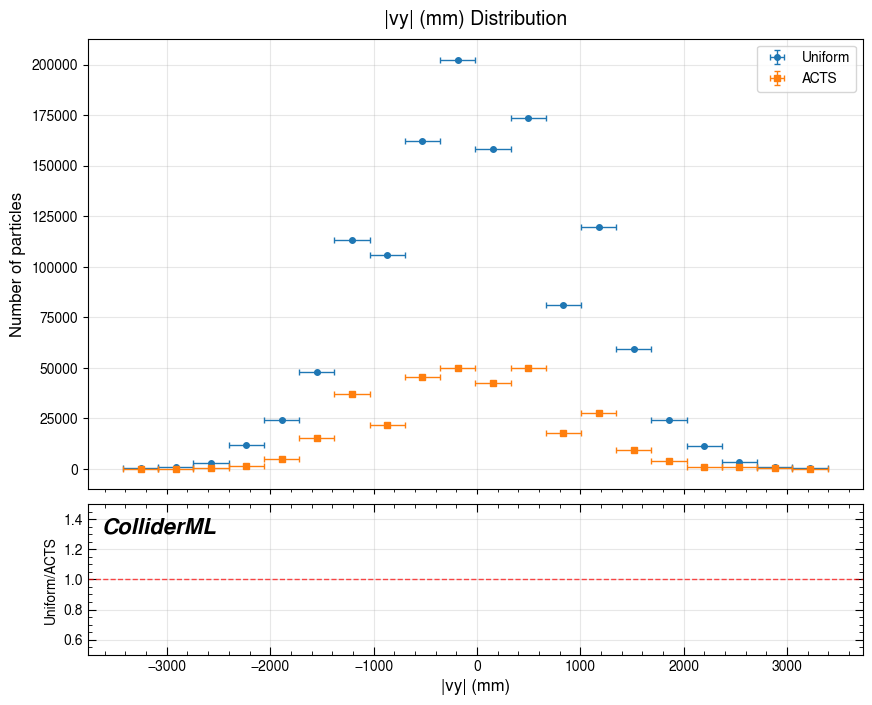

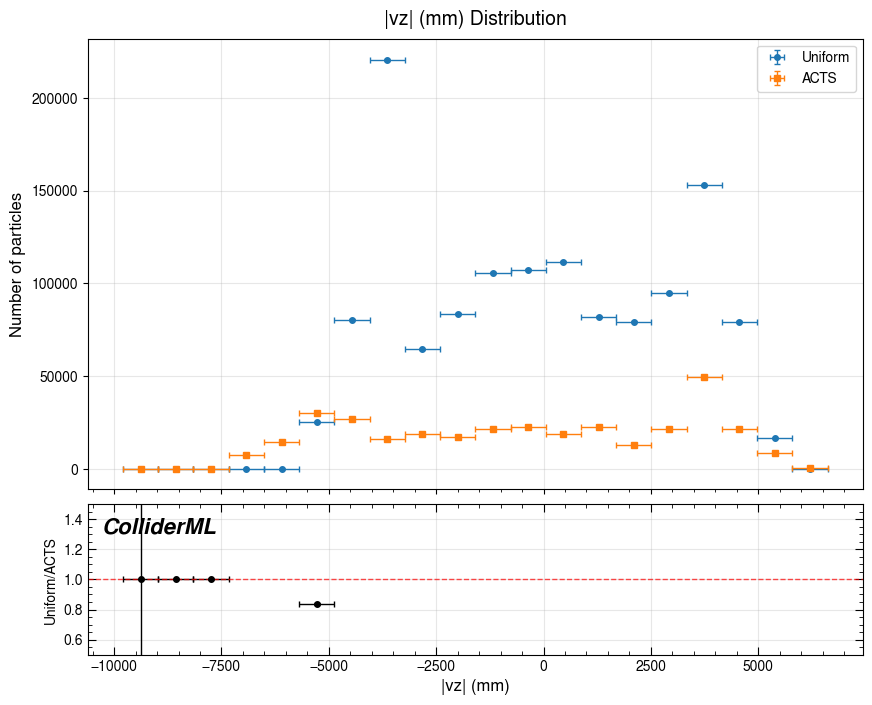

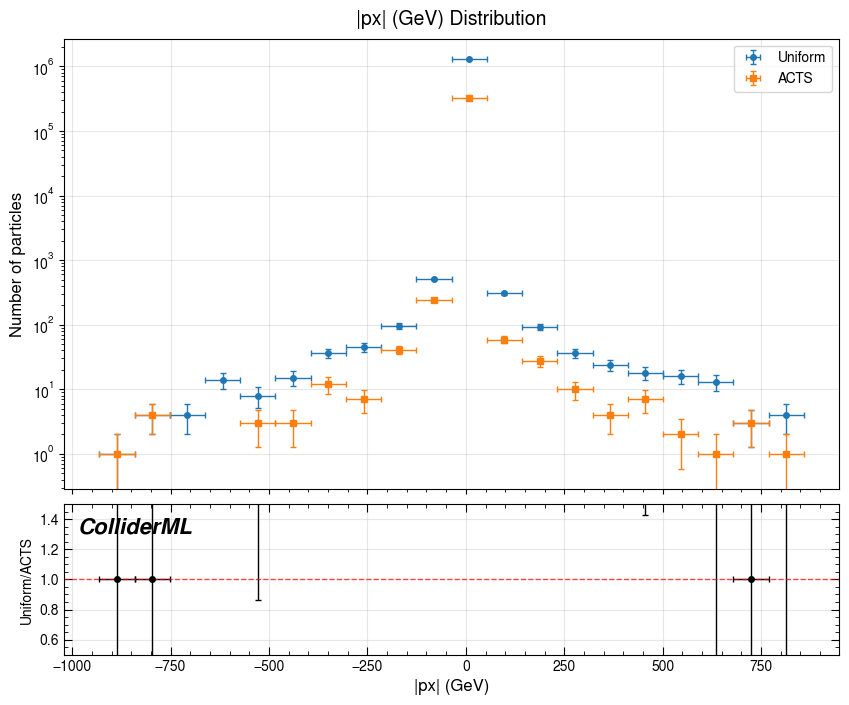

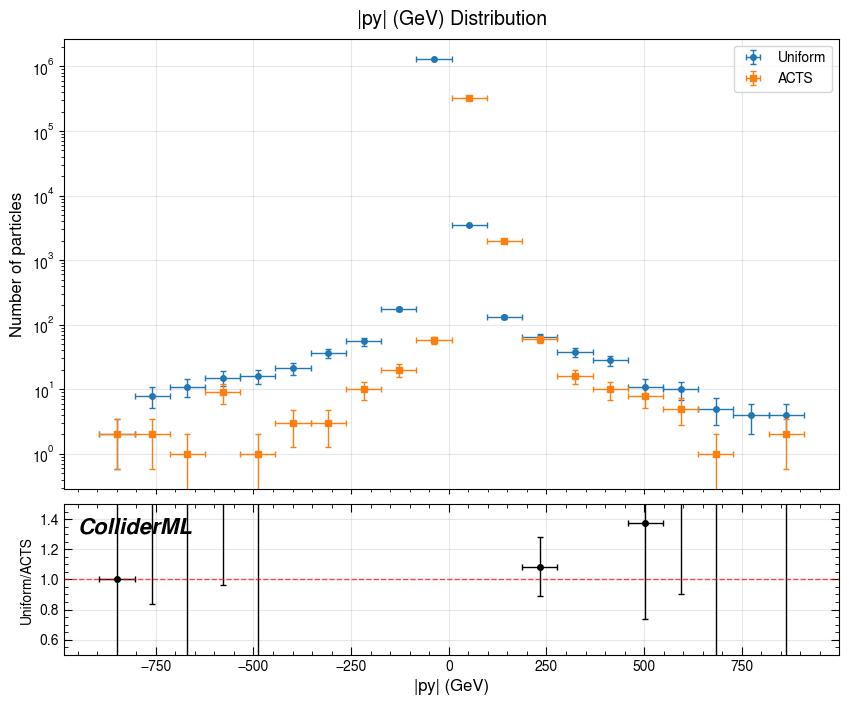

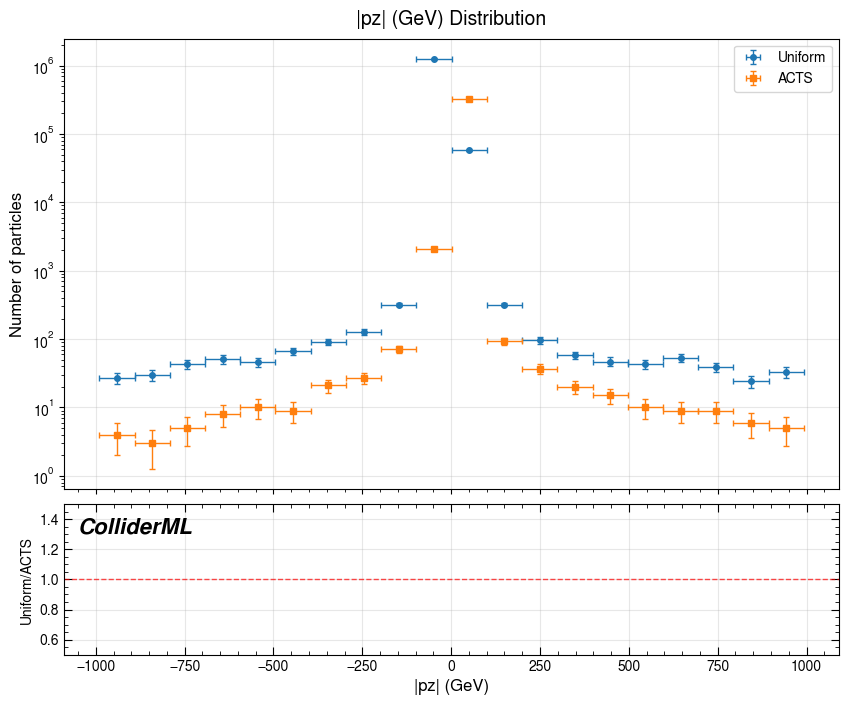

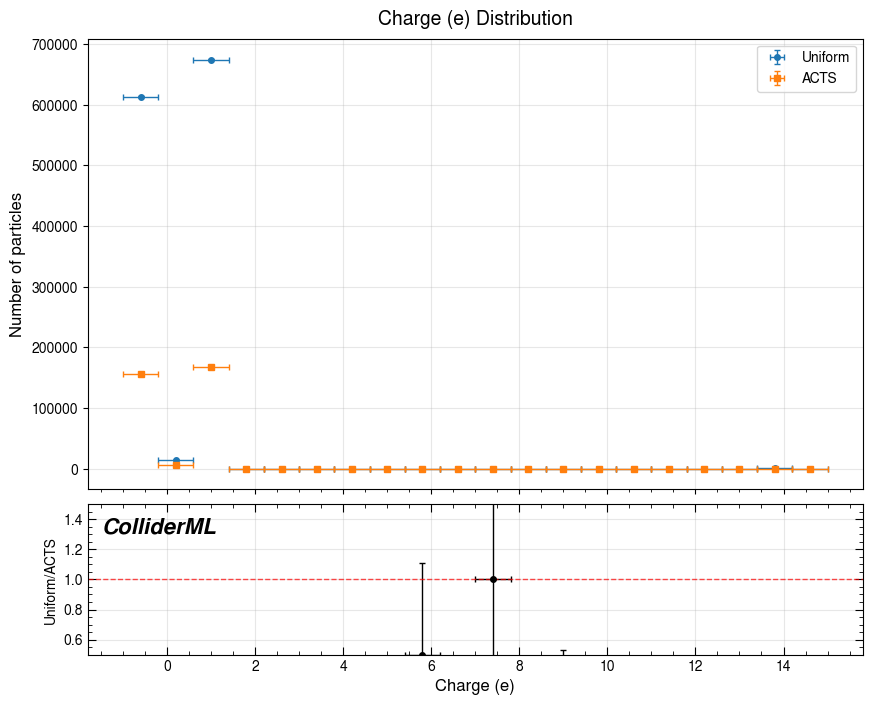

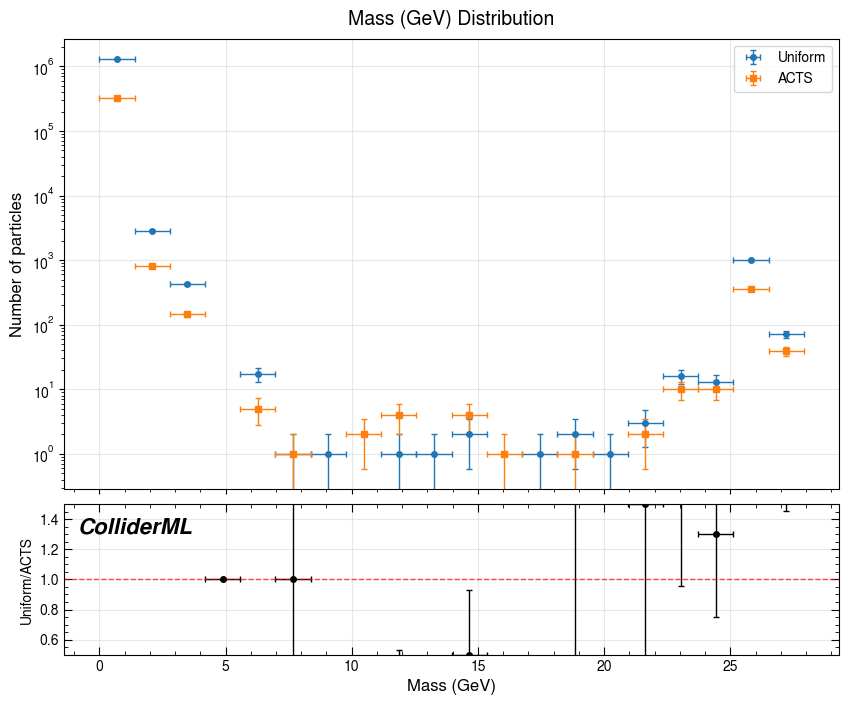

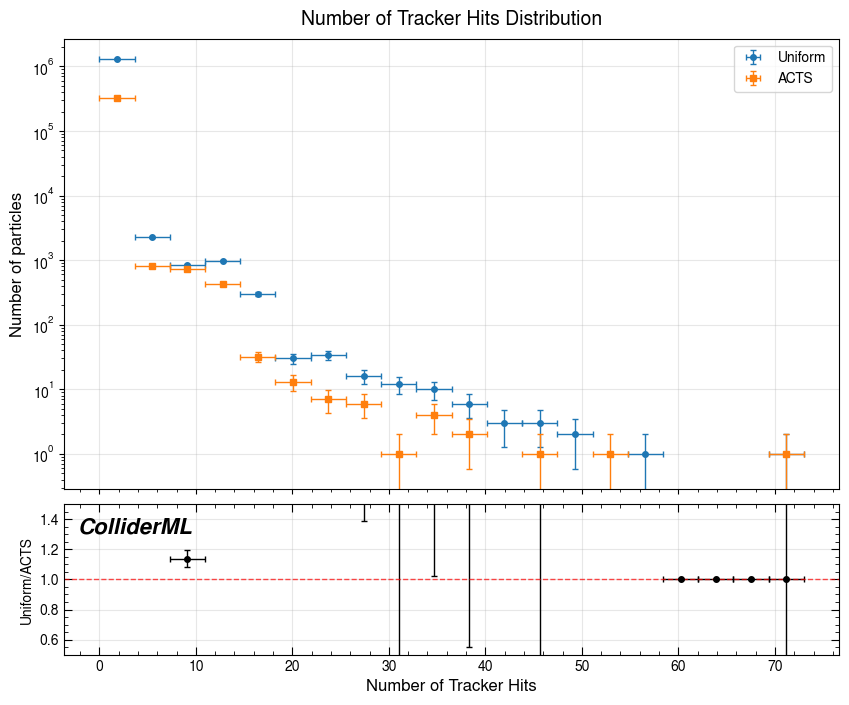

In [70]:
# Define columns to plot with their properties
plot_configs = [
    {'col': 'vx', 'label': '|vx| (mm)', 'log': False, 'abs': True},
    {'col': 'vy', 'label': '|vy| (mm)', 'log': False, 'abs': True},
    {'col': 'vz', 'label': '|vz| (mm)', 'log': False, 'abs': True},
    {'col': 'px', 'label': '|px| (GeV)', 'log': True, 'abs': True},
    {'col': 'py', 'label': '|py| (GeV)', 'log': True, 'abs': True},
    {'col': 'pz', 'label': '|pz| (GeV)', 'log': True, 'abs': True},
    {'col': 'charge', 'label': 'Charge (e)', 'log': False, 'abs': False},
    {'col': 'mass', 'label': 'Mass (GeV)', 'log': True, 'abs': False},
    {'col': 'num_tracker_hits', 'label': 'Number of Tracker Hits', 'log': True, 'abs': False},
]

for config in plot_configs:
    col = config['col']
    label = config['label']
    use_log = config['log']
    use_abs = config['abs']
    if use_abs:
        native_data = np.abs(native_particles[col])
        acts_data = np.abs(acts_loguniform_particles[col])
    else:
        native_data = native_particles[col]
        acts_data = acts_loguniform_particles[col]
    
    plot_comparison_with_ratio(
        acts_particles[col],
        acts_loguniform_particles[col],
        xlabel=label,
        ylabel="Number of particles",
        title=f"{label} Distribution",
        bins=20,
        log_scale=use_log,
        label1="Uniform",
        label2="ACTS",
    )

## ACTS Simulation Detailed Analysis


In [7]:
# Question 6: How many particles per event are created in simulation?
particles_created_in_sim_per_event = acts_particles[acts_particles['created_in_simulation'] == True].groupby('event_id').size()

print("=" * 80)
print("PARTICLES CREATED IN SIMULATION (ACTS)")
print("=" * 80)
print(f"\nStatistics per event:")
print(particles_created_in_sim_per_event.describe())
print(f"\nMean particles created in simulation per event: {particles_created_in_sim_per_event.mean():.2f}")
print(f"Median particles created in simulation per event: {particles_created_in_sim_per_event.median():.2f}")
print(f"\nBreakdown per event:")
for event_id, count in particles_created_in_sim_per_event.items():
    print(f"  Event {event_id}: {count} particles")


PARTICLES CREATED IN SIMULATION (ACTS)

Statistics per event:
count     967.000000
mean     1345.802482
std       861.875641
min         1.000000
25%       572.500000
50%      1291.000000
75%      2038.500000
max      3912.000000
dtype: float64

Mean particles created in simulation per event: 1345.80
Median particles created in simulation per event: 1291.00

Breakdown per event:
  Event 0: 147 particles
  Event 1: 173 particles
  Event 2: 474 particles
  Event 3: 77 particles
  Event 4: 746 particles
  Event 5: 476 particles
  Event 6: 120 particles
  Event 7: 1643 particles
  Event 8: 1641 particles
  Event 9: 935 particles
  Event 10: 243 particles
  Event 11: 1220 particles
  Event 12: 1745 particles
  Event 13: 960 particles
  Event 14: 385 particles
  Event 15: 833 particles
  Event 16: 2421 particles
  Event 17: 854 particles
  Event 18: 1000 particles
  Event 19: 1086 particles
  Event 20: 2550 particles
  Event 21: 1763 particles
  Event 22: 302 particles
  Event 24: 1731 parti

In [8]:
# Question 7: How many particles per event are created in the tracker?
if 'created_inside_tracker' in acts_particles.columns:
    particles_created_in_tracker_per_event = acts_particles[acts_particles['created_inside_tracker'] == True].groupby('event_id').size()
    
    print("=" * 80)
    print("PARTICLES CREATED IN TRACKER (ACTS)")
    print("=" * 80)
    print(f"\nStatistics per event:")
    print(particles_created_in_tracker_per_event.describe())
    print(f"\nMean particles created in tracker per event: {particles_created_in_tracker_per_event.mean():.2f}")
    print(f"Median particles created in tracker per event: {particles_created_in_tracker_per_event.median():.2f}")
    print(f"\nBreakdown per event:")
    for event_id, count in particles_created_in_tracker_per_event.items():
        print(f"  Event {event_id}: {count} particles")
else:
    print("Column 'created_inside_tracker' not found in ACTS particles dataframe")


PARTICLES CREATED IN TRACKER (ACTS)

Statistics per event:
count    1000.000000
mean       39.141000
std        73.628597
min         2.000000
25%         4.000000
50%        12.000000
75%        40.000000
max       840.000000
dtype: float64

Mean particles created in tracker per event: 39.14
Median particles created in tracker per event: 12.00

Breakdown per event:
  Event 0: 3 particles
  Event 1: 3 particles
  Event 2: 19 particles
  Event 3: 5 particles
  Event 4: 7 particles
  Event 5: 21 particles
  Event 6: 2 particles
  Event 7: 6 particles
  Event 8: 3 particles
  Event 9: 3 particles
  Event 10: 29 particles
  Event 11: 52 particles
  Event 12: 43 particles
  Event 13: 5 particles
  Event 14: 95 particles
  Event 15: 57 particles
  Event 16: 113 particles
  Event 17: 2 particles
  Event 18: 47 particles
  Event 19: 60 particles
  Event 20: 10 particles
  Event 21: 120 particles
  Event 22: 157 particles
  Event 23: 2 particles
  Event 24: 23 particles
  Event 25: 11 particles

In [9]:
# Question 8: How many events have the primary particle not reaching the calo?
# Primary particles are those NOT created in simulation
primary_particles = acts_particles[acts_particles['created_in_simulation'] == False]

print("=" * 80)
print("PRIMARY PARTICLE CALO ANALYSIS (ACTS)")
print("=" * 80)

# For each event, check if the primary particle reached the calo
events_with_primary_no_calo = []
total_events = len(primary_particles['event_id'].unique())

for event_id in primary_particles['event_id'].unique():
    event_primary = primary_particles[primary_particles['event_id'] == event_id]
    # Check if any primary particle in this event has calo hits
    has_calo_hits = (event_primary['num_calo_hits'] > 0).any()
    if not has_calo_hits:
        events_with_primary_no_calo.append(event_id)

num_events_no_calo = len(events_with_primary_no_calo)
fraction_no_calo = num_events_no_calo / total_events if total_events > 0 else 0

print(f"\nTotal events with primary particles: {total_events}")
print(f"Events where primary particle(s) did NOT reach calo: {num_events_no_calo}")
print(f"Fraction of events with no calo hits from primary: {fraction_no_calo:.2%}")
print(f"Average: {fraction_no_calo:.2%} of events have primary particles not reaching the calo")

if events_with_primary_no_calo:
    print(f"\nEvent IDs where primary did not reach calo: {events_with_primary_no_calo}")


PRIMARY PARTICLE CALO ANALYSIS (ACTS)

Total events with primary particles: 1000
Events where primary particle(s) did NOT reach calo: 1000
Fraction of events with no calo hits from primary: 100.00%
Average: 100.00% of events have primary particles not reaching the calo

Event IDs where primary did not reach calo: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64

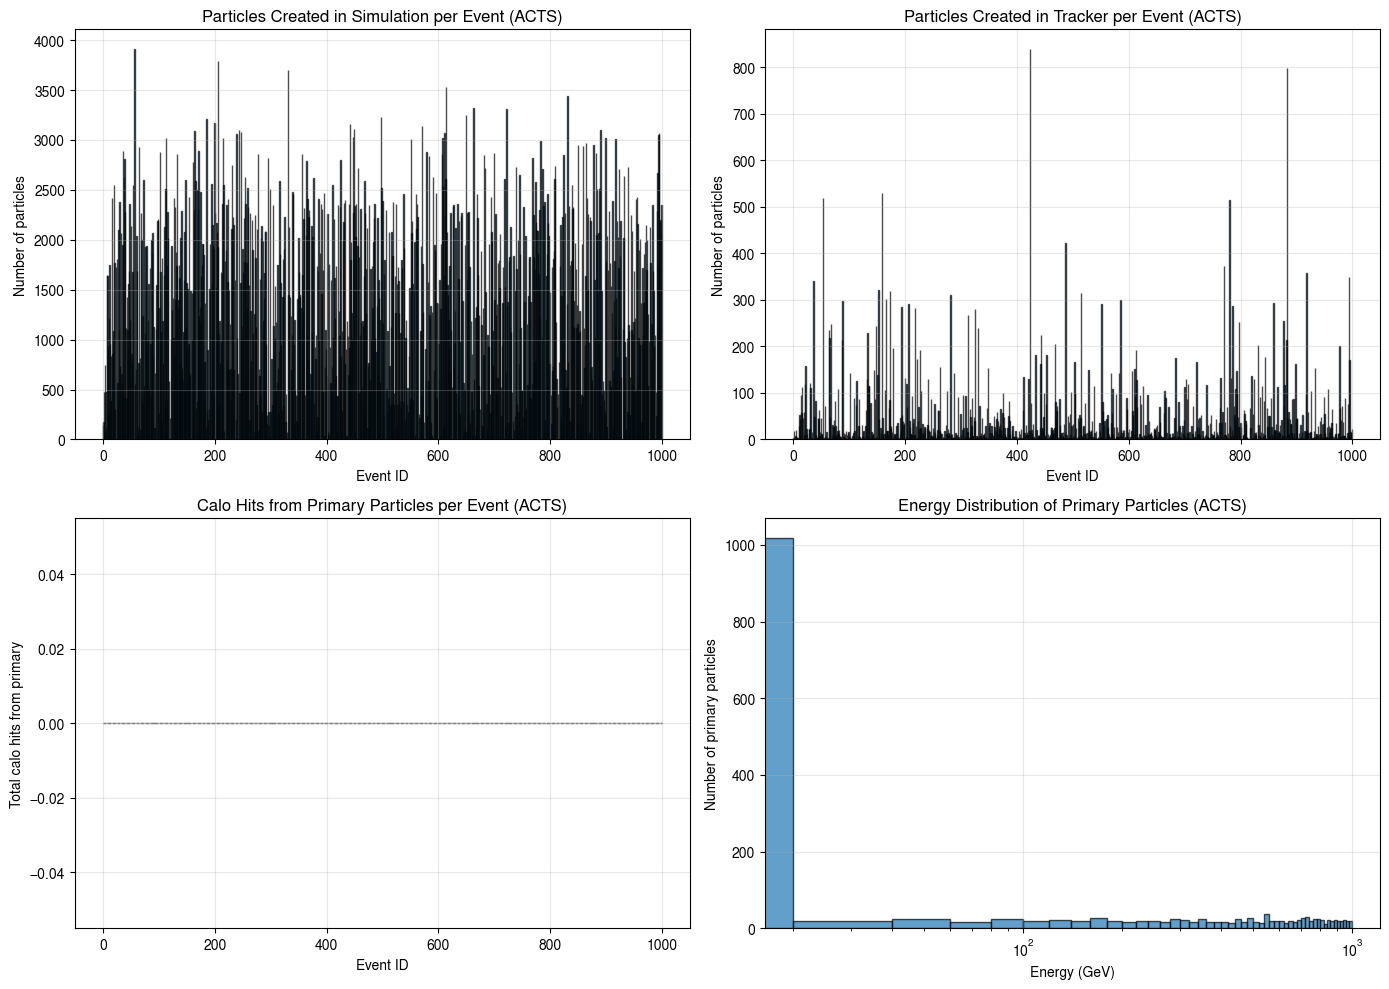

In [10]:
# Additional visualization for ACTS analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Particles created in simulation per event
axes[0, 0].bar(particles_created_in_sim_per_event.index, particles_created_in_sim_per_event.values, 
               edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Event ID')
axes[0, 0].set_ylabel('Number of particles')
axes[0, 0].set_title('Particles Created in Simulation per Event (ACTS)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Particles created in tracker per event
if 'created_inside_tracker' in acts_particles.columns:
    axes[0, 1].bar(particles_created_in_tracker_per_event.index, particles_created_in_tracker_per_event.values,
                   edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Event ID')
    axes[0, 1].set_ylabel('Number of particles')
    axes[0, 1].set_title('Particles Created in Tracker per Event (ACTS)')
    axes[0, 1].grid(True, alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Particles Created in Tracker per Event (ACTS)')

# Plot 3: Primary particles calo hits
primary_calo_hits = primary_particles.groupby('event_id')['num_calo_hits'].sum()
axes[1, 0].bar(primary_calo_hits.index, primary_calo_hits.values, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Event ID')
axes[1, 0].set_ylabel('Total calo hits from primary')
axes[1, 0].set_title('Calo Hits from Primary Particles per Event (ACTS)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Distribution of primary particle energies
axes[1, 1].hist(primary_particles['energy'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Energy (GeV)')
axes[1, 1].set_ylabel('Number of primary particles')
axes[1, 1].set_title('Energy Distribution of Primary Particles (ACTS)')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

This notebook compares ACTS and Native simulations for single particle (pion) events:

1. Loaded both ACTS (v1) and Native (v2) simulation data
2. Printed detailed statistics for hits and particles in both simulations
3. Compared key metrics between the two simulations
4. Created comparison plots for:
   - Hits and particles per event distributions
   - Energy distributions
   - Tracker hits per particle
5. Analyzed ACTS simulation in detail:
   - Particles created in simulation per event
   - Particles created in tracker per event
   - Events where primary particles did not reach the calorimeter
